In [6]:
# netPCF import
import spacenet as sn

# other imports
import numpy as np
import matplotlib.pyplot as plt 

np.random.seed(3)  # For reproducibility
plt.rcParams['figure.dpi'] = 200

max_dist = 100
edge_distance = 150

kernel_n = 2
r_step=5

scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=1,marker_size=15,add_node_cbar=False,edge_weight_name='Distance',scatter_kwargs=scatter_kwargs) 
scalebar_kwargs = dict(size=100, label='',loc='lower right',pad = 1.5,frameon=False,size_vertical=10,zorder=1000)

edge_width=0.5

# domain parameters
region_size = (1000, 1000)
muspan_domain_boundary = np.array([[0, 0],
                                    [region_size[0], 0],
                                    [region_size[0], region_size[1]],
                                    [0, region_size[1]]])

# Poisson point pattern parameters
lambda_points = 0.003  # Density of points

# background PPP
num_points = int(region_size[0] * region_size[1] * lambda_points)

##### Points PPP ######

# Generate points using a Poisson point process
points = np.random.uniform(0, region_size[0], size=(num_points, 2))

ppp_points = points 


G_ppp=sn.utils.spatial_network_from_points(ppp_points,network_type='delaunay',max_edge_distance=edge_distance)


# getting edge data to define bandwidths
edge_weights = [data['Distance'] for _, _, data in G_ppp.edges(data=True)]
upper_95_CI = 2*np.mean(edge_weights) - np.nanpercentile(edge_weights, 2.5, axis=0)
characteristic_length = np.mean(edge_weights)  # Example characteristic length based on mean edge length

delta_r_min = sn.point_patterns.helpers.polynomial_kernel_bandwidth_scale(kernel_n,0.75) *characteristic_length  # Example bandwidth based on mean edge length
bandwidths = [0.5*delta_r_min, 1*delta_r_min,1.5*delta_r_min]  # Example bandwidths for the kernel

netPCF_kwargs_1 = dict(spatial_kernel_bandwidth=bandwidths[0],
                        spatial_kernel_n=kernel_n,
                        r_min=0, 
                        r_max=max_dist,
                        r_step=r_step, 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1) 

netPCF_kwargs_2 = dict(spatial_kernel_bandwidth=bandwidths[1],
                        spatial_kernel_n=kernel_n,
                        r_min=0, 
                        r_max=max_dist,
                        r_step=r_step, 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1) 

netPCF_kwargs_3 = dict(spatial_kernel_bandwidth=bandwidths[2],
                        spatial_kernel_n=kernel_n,
                        r_min=0, 
                        r_max=max_dist,
                        r_step=r_step, 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1) 

kernel_args = [netPCF_kwargs_1,netPCF_kwargs_2,netPCF_kwargs_3]



objects_indices_ppp = np.arange(len(points))    

# compute netPCF
r_list = []
g_list = [] 
CI_list = []    
for i in range(len(bandwidths)):
    r1,g1,CI1 = sn.point_patterns.cross_pair_correlation_function(G_ppp,
                                                    nodes_a=objects_indices_ppp,
                                                    nodes_b=objects_indices_ppp,
                                                    **kernel_args[i])
    r_list.append(r1)
    g_list.append(g1)   
    CI_list.append(CI1)

Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 3000/3000 [00:07<00:00, 382.12contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 3000/3000 [00:08<00:00, 345.78contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 3000/3000 [00:07<00:00, 384.07contributions/s]

Computing confidence intervals via spatial bootstrap...


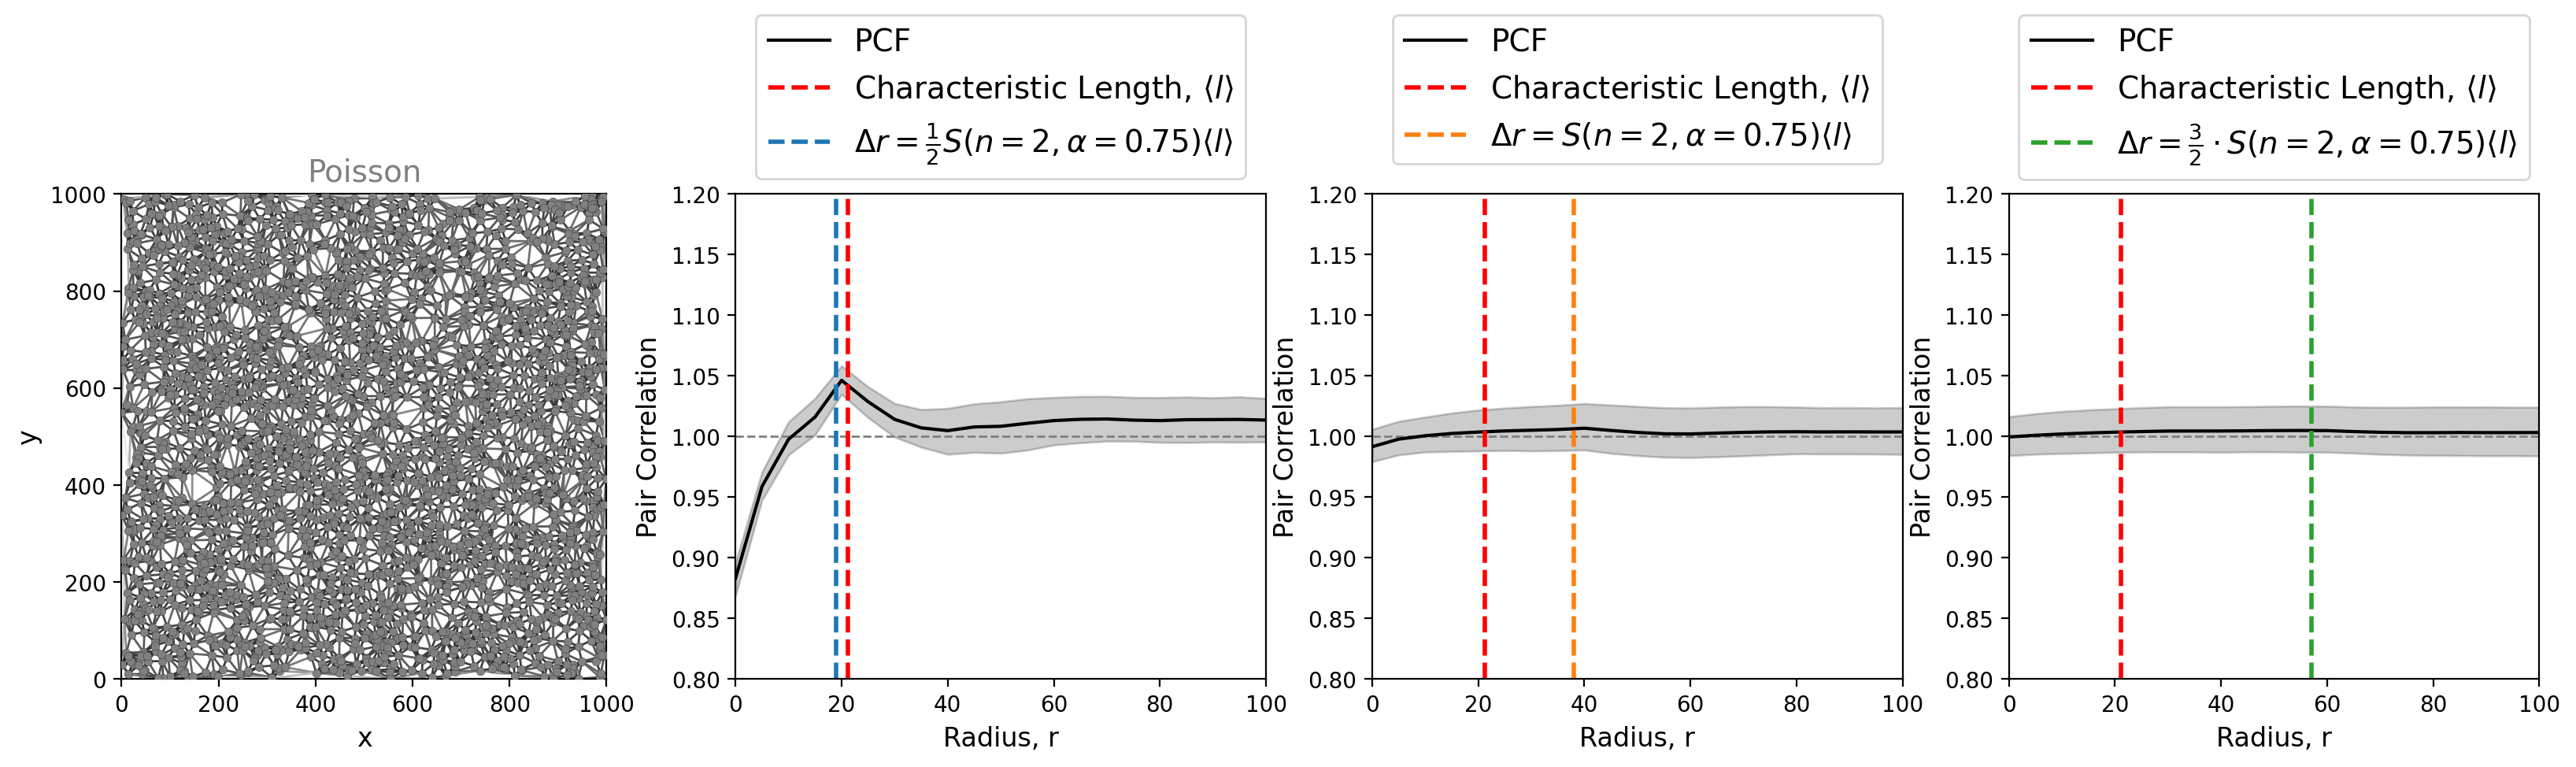

In [7]:
# Create a figure for the plots
fig,ax=plt.subplots(1,4,figsize=(20,4))

# Create a 3x3 grid of subplots
# Plot CSR
sn.utils.plot_spatial_network(G_ppp,ax=ax[0],**visualise_paras)
ax[0].scatter(points[:,0],points[:,1],color='black',s=10,edgecolors='black',linewidths=0.1)


# Turn on axis spines
ax[0].set_axis_on()
ax[0].set_xlabel('x',fontsize=12)
ax[0].set_ylabel('y',fontsize=12)
ax[0].set_xlim(0, region_size[0]) 
ax[0].set_ylim(0, region_size[1]) 
ax[0].set_title('Poisson',color='grey',fontsize=14)


colors = ['tab:blue', 'tab:orange', 'tab:green']    
labels= ['$\\Delta r =  \\frac{1}{2}S(n=2,\\alpha=0.75) \\langle l \\rangle$',
         '$\\Delta r =  S(n=2,\\alpha=0.75) \\langle l \\rangle$',
         '$\\Delta r =  \\frac{3}{2} \\cdot S(n=2,\\alpha=0.75) \\langle l \\rangle$']


ax[1].axhline(1, color='gray', linestyle='--', linewidth=1)    

ax[1].plot(r_list[0],g_list[0],label='PCF',color='k') 
ax[1].fill_between(r_list[0], CI_list[0][0], CI_list[0][1], alpha=0.2,color='k')

ax[1].axvline(characteristic_length , color='red', linestyle='--', linewidth=2,label='Characteristic Length, $\\langle l \\rangle$')
ax[1].axvline(bandwidths[0], color=colors[0], linestyle='--', linewidth=2,label=labels[0])

ax[1].set_xlabel('Radius, r',fontsize=12)
ax[1].set_ylabel('Pair Correlation',fontsize=12)
ax[1].set_xlim(0, max_dist)  
ax[1].set_ylim(0.8,1.2)
ax[1].legend(fontsize=14,loc='upper center',bbox_to_anchor=(0.5, 1.4),ncol=1)


# 
ax[2].axhline(1, color='gray', linestyle='--', linewidth=1)    

ax[2].plot(r_list[1],g_list[1],label='PCF',color='k') 
ax[2].fill_between(r_list[1], CI_list[1][0], CI_list[1][1], alpha=0.2,color='k')

ax[2].axvline(characteristic_length , color='red', linestyle='--', linewidth=2,label='Characteristic Length, $\\langle l \\rangle$')
ax[2].axvline(bandwidths[1], color=colors[1], linestyle='--', linewidth=2,label=labels[1])

ax[2].set_xlabel('Radius, r',fontsize=12)
ax[2].set_ylabel('Pair Correlation',fontsize=12)
ax[2].set_xlim(0, max_dist)  
ax[2].set_ylim(0.8,1.2)
ax[2].legend(fontsize=14,loc='upper center',bbox_to_anchor=(0.5, 1.4),ncol=1)



ax[3].axhline(1, color='gray', linestyle='--', linewidth=1)    

ax[3].plot(r_list[2],g_list[2],label='PCF',color='k') 
ax[3].fill_between(r_list[2], CI_list[2][0], CI_list[2][1], alpha=0.2,color='k')
ax[3].axvline(characteristic_length , color='red', linestyle='--', linewidth=2,label='Characteristic Length, $\\langle l \\rangle$')
ax[3].axvline(bandwidths[2], color=colors[2], linestyle='--', linewidth=2,label=labels[2])
ax[3].set_xlabel('Radius, r',fontsize=12)
ax[3].set_ylabel('Pair Correlation',fontsize=12)
ax[3].set_xlim(0, max_dist)  
ax[3].set_ylim(0.8,1.2)
ax[3].legend(fontsize=14,loc='upper center',bbox_to_anchor=(0.5, 1.4),ncol=1)  

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/sufficient_coverage/netPCF_bandwidth_sensitivity.png',dpi=300,bbox_inches='tight')

### Kernel intergal plots

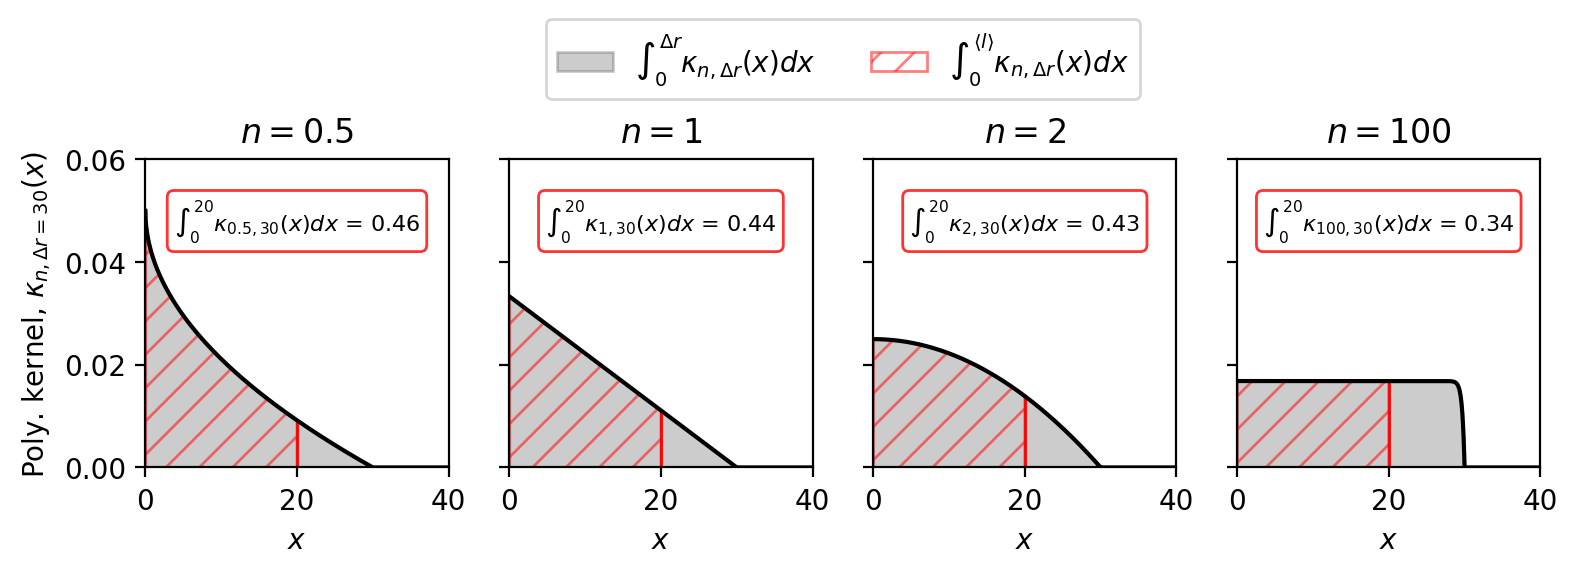

In [10]:



def integated_kernel(x,n):
    return (1/(2*n))*(x *(n+1) - x**(n+1) )

fig,ax=plt.subplots(1,4,figsize=(9,2),sharex=True,sharey=True)


bandwidth=30
line_length=20

x=np.linspace(0, 40, 1000)
l=np.linspace(0, line_length, 1000)

ax[0].fill_between(x,np.zeros(len(x)),sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(0.5), delta_r=np.float64(bandwidth)),alpha=0.2,color='black',label="$ \\int_{0}^{\\Delta r} \\kappa_{n,\\Delta r}(x) dx$")
ax[0].fill_between(l,np.zeros(len(l)),sn.point_patterns.helpers.polynomial_kernel(l, n=np.float64(0.5), delta_r=np.float64(bandwidth)),alpha=0.5,facecolor='none',edgecolor='red',hatch='//',label="$ \\int_{0}^{\\langle l \\rangle} \\kappa_{n,\\Delta r}(x) dx$")
ax[0].plot([line_length,line_length],[0,sn.point_patterns.helpers.polynomial_kernel(line_length, n=np.float64(0.5), delta_r=np.float64(bandwidth))],color='red',linewidth=1)
ax[0].plot(x,sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(0.5), delta_r=np.float64(bandwidth)),color='k')
ax[0].text(0.5, 0.8, '$ \\int_{0}^{20} \\kappa_{0.5,30}(x) dx$ = ' + f'{round(integated_kernel(20/30, 0.5), 2)}', fontsize=8, transform=ax[0].transAxes, ha='center', va='center',bbox=dict(boxstyle='round', facecolor='white',edgecolor='red', alpha=0.8))

ax[1].fill_between(x,np.zeros(len(x)),sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(1), delta_r=np.float64(bandwidth)),alpha=0.2,color='black',label="$ \\int_{0}^{\\Delta r} \\kappa_{n,\\Delta r}(x) dx$")
ax[1].fill_between(l,np.zeros(len(l)),sn.point_patterns.helpers.polynomial_kernel(l, n=np.float64(1), delta_r=np.float64(bandwidth)),alpha=0.5,facecolor='none',edgecolor='red',hatch='//',label="$ \\int_{0}^{\\langle l \\rangle} \\kappa_{n,\\Delta r}(x) dx$")
ax[1].plot([line_length,line_length],[0,sn.point_patterns.helpers.polynomial_kernel(line_length, n=np.float64(1), delta_r=np.float64(bandwidth))],color='red',linewidth=1)
ax[1].plot(x,sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(1), delta_r=np.float64(bandwidth)),color='k')
ax[1].text(0.5, 0.8, '$ \\int_{0}^{20} \\kappa_{1,30}(x) dx$ = ' + f'{round(integated_kernel(20/30, 1), 2)}', fontsize=8, transform=ax[1].transAxes, ha='center', va='center',bbox=dict(boxstyle='round', facecolor='white',edgecolor='red', alpha=0.8))



ax[2].fill_between(x,np.zeros(len(x)),sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(2), delta_r=np.float64(bandwidth)),alpha=0.2,color='black',label="$ \\int_{0}^{\\Delta r} \\kappa_{n,\\Delta r}(x) dx$")
ax[2].fill_between(l,np.zeros(len(l)),sn.point_patterns.helpers.polynomial_kernel(l, n=np.float64(2), delta_r=np.float64(bandwidth)),alpha=0.5,facecolor='none',edgecolor='red',hatch='//',label="$ \\int_{0}^{\\langle l \\rangle} \\kappa_{n,\\Delta r}(x) dx$")
ax[2].plot([line_length,line_length],[0,sn.point_patterns.helpers.polynomial_kernel(line_length, n=np.float64(2), delta_r=np.float64(bandwidth))],color='red',linewidth=1)
ax[2].plot(x,sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(2), delta_r=np.float64(bandwidth)),color='k')
ax[2].text(0.5, 0.8, '$ \\int_{0}^{20} \\kappa_{2,30}(x) dx$ = ' + f'{round(integated_kernel(20/30, 2), 2)}', fontsize=8, transform=ax[2].transAxes, ha='center', va='center',bbox=dict(boxstyle='round', facecolor='white',edgecolor='red', alpha=0.8))



ax[3].fill_between(x,np.zeros(len(x)),sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(100), delta_r=np.float64(bandwidth)),alpha=0.2,color='black',label="$ \\int_{0}^{\\Delta r} \\kappa_{n,\\Delta r}(x) dx$")
ax[3].fill_between(l,np.zeros(len(l)),sn.point_patterns.helpers.polynomial_kernel(l, n=np.float64(100), delta_r=np.float64(bandwidth)),alpha=0.5,facecolor='none',edgecolor='red',hatch='//',label="$ \\int_{0}^{\\langle l \\rangle} \\kappa_{n,\\Delta r}(x) dx$")
ax[3].plot([line_length,line_length],[0,sn.point_patterns.helpers.polynomial_kernel(line_length, n=np.float64(100), delta_r=np.float64(bandwidth))],color='red',linewidth=1)
ax[3].plot(x,sn.point_patterns.helpers.polynomial_kernel(x, n=np.float64(100), delta_r=np.float64(bandwidth)),color='k')
ax[3].text(0.5, 0.8, '$ \\int_{0}^{20} \\kappa_{100,30}(x) dx$ = ' + f'{round(integated_kernel(20/30, 100), 2)}', fontsize=8, transform=ax[3].transAxes, ha='center', va='center',bbox=dict(boxstyle='round', facecolor='white',edgecolor='red', alpha=0.8))



ax[0].set_ylim(0,0.06)
ax[1].set_ylim(0,0.06)
ax[2].set_ylim(0,0.06)
ax[3].set_ylim(0,0.06)

ax[0].set_xlim(0,40)
ax[1].set_xlim(0,40)
ax[2].set_xlim(0,40)
ax[3].set_xlim(0,40)

ax[0].set_ylabel("Poly. kernel, $\\kappa_{n,\\Delta r = 30}(x)$")
ax[0].set_xlabel("$x$")
ax[1].set_xlabel("$x$")
ax[2].set_xlabel("$x$")
ax[3].set_xlabel("$x$")

ax[0].set_title("$n=0.5$")
ax[1].set_title("$n=1$")
ax[2].set_title("$n=2$")
ax[3].set_title("$n=100$")

ax[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(2.3, 1.5))

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/sufficient_coverage/kernel_mass.png', dpi=300, bbox_inches='tight')   

# numerical root finding for bandwidth lower bounds

/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_47558/320872805.py:37: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(n_values, 1/roots_0, label='Numeric root: $\\alpha=0.5$',color='tab:blue',edgecolors='black',zorder=10,s=15,linewidths=1,marker='x')
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_47558/320872805.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(n_values, 1/roots_1, label='Numeric root: $\\alpha=0.7$',color='tab:orange',edgecolors='black',zorder=10,s=15,linewidths=1,marker='x')
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_47558/320872805.py:39: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled m

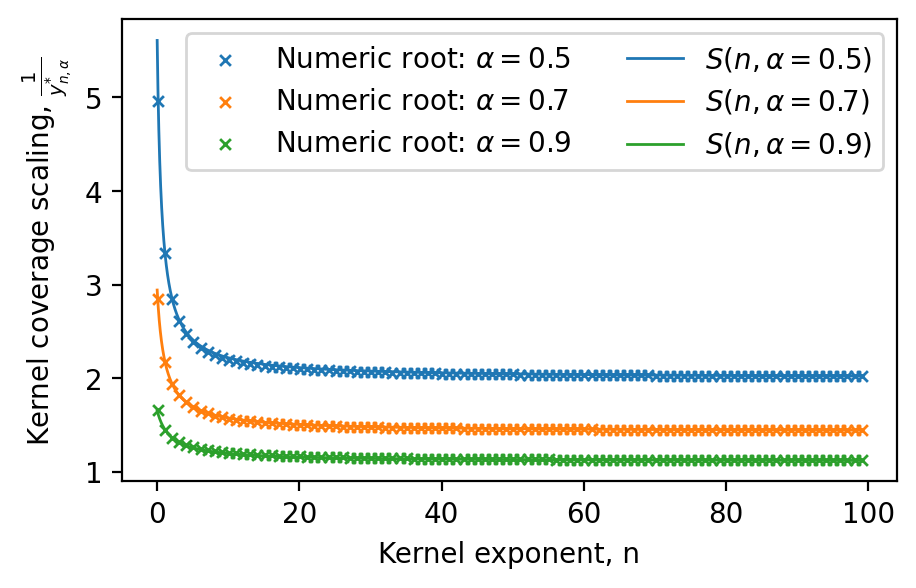

In [14]:
from scipy.optimize import root_scalar

# Define the function f
def f(x, a, n):
    return x**(n + 1) - (n + 1) * x + a * n

n_values=np.arange(0.1,100,1)

roots_0 = []
roots_1 = []
roots_2 = []

for n in n_values:
    root_0 = root_scalar(f, args=(0.5, n), bracket=[0, 1], method='bisect')
    root_1 = root_scalar(f, args=(0.7, n), bracket=[0, 1], method='bisect')
    root_2 = root_scalar(f, args=(0.9, n), bracket=[0, 1], method='bisect')
    
    roots_0.append(root_0.root)
    roots_1.append(root_1.root)
    roots_2.append(root_2.root)

roots_0 = np.array(roots_0)
roots_1 = np.array(roots_1)
roots_2 = np.array(roots_2)

n_value_continuous = np.arange(0,np.max(n_values),0.01)

def ansatz_root_inverse(n,alpha):
    c1= (1/ (1 - np.sqrt(1-alpha))  ) - 1/alpha
    c2 = 1/ (2*np.cos( (1/3) *( 5*np.pi - np.arccos(alpha))  )) - 1/alpha
    B = (2*c2 - c1)/(c1-c2)
    A = c1*(B+1)
    return A / (B + n) + 1/alpha


fig,ax=plt.subplots(figsize=(5,3))
ax.scatter(n_values, 1/roots_0, label='Numeric root: $\\alpha=0.5$',color='tab:blue',edgecolors='black',zorder=10,s=15,linewidths=1,marker='x')    
ax.scatter(n_values, 1/roots_1, label='Numeric root: $\\alpha=0.7$',color='tab:orange',edgecolors='black',zorder=10,s=15,linewidths=1,marker='x')
ax.scatter(n_values, 1/roots_2, label='Numeric root: $\\alpha=0.9$',color='tab:green',edgecolors='black',zorder=10,s=15,linewidths=1,marker='x')  

ax.plot(n_value_continuous,ansatz_root_inverse(n_value_continuous,0.5), label='$S(n, \\alpha = 0.5)$',color='tab:blue',linestyle='-',linewidth=1)
ax.plot(n_value_continuous,ansatz_root_inverse(n_value_continuous,0.7), label='$S(n, \\alpha = 0.7)$',color='tab:orange',linestyle='-',linewidth=1)
ax.plot(n_value_continuous,ansatz_root_inverse(n_value_continuous,0.9), label='$S(n, \\alpha = 0.9)$',color='tab:green',linestyle='-',linewidth=1)


ax.set_xlabel('Kernel exponent, n') 
ax.set_ylabel('Kernel coverage scaling, $\\frac{1}{y^{*}_{n,\\alpha}}$')
ax.legend(ncol=2)   


#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/sufficient_coverage/numerical_approx.png', dpi=300, bbox_inches='tight')   

